<a href="https://colab.research.google.com/github/awinarko-hue/AI-Monitoring-Balmon-Yogyakarta-V.1.0/blob/main/NLP/ClusterRegex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter


In [ ]:
# =========================
# 1. LOAD DATA
# =========================
file_path = "/content/drive/MyDrive/Dataset/Shopee/Scrap/Gagal/1dataset_gabungan.csv"  # ganti sesuai lokasi file
df = pd.read_csv(file_path)

# gunakan kolom pertama
col = df.columns[0]


In [ ]:
# =========================
# 2. NLP: EXTRACT FAMILY NAME
# =========================
def extract_family_name(title):
    text = str(title).lower()

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus tanda baca
    text = re.sub(r'[^\w\s]', '', text)

    # daftar kata yang dihapus (variant & noise)
    remove_words = [
        "mah", "km", "pcs", "pack", "paket", "original", "copy",
        "type", "charge", "baterai", "battery", "unit", "double",
        "terjual", "walkie", "talkie",
    ]

    tokens = text.split()

    # hapus kata noise
    tokens = [t for t in tokens if t not in remove_words]

    return " ".join(tokens)

# terapkan ke dataset
df["product_family"] = df[col].apply(extract_family_name)

In [ ]:
# =========================
# 3. GROUPING
# =========================
counts = Counter(df["product_family"])

# ubah ke dataframe
group_df = pd.DataFrame(counts.items(), columns=["Product Family", "Jumlah Produk"])
group_df = group_df.sort_values(by="Jumlah Produk", ascending=False)

# simpan hasil grouping
group_df.to_csv("hasil_grouping.csv", index=False)

/tmp/ipykernel_567/2334367563.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


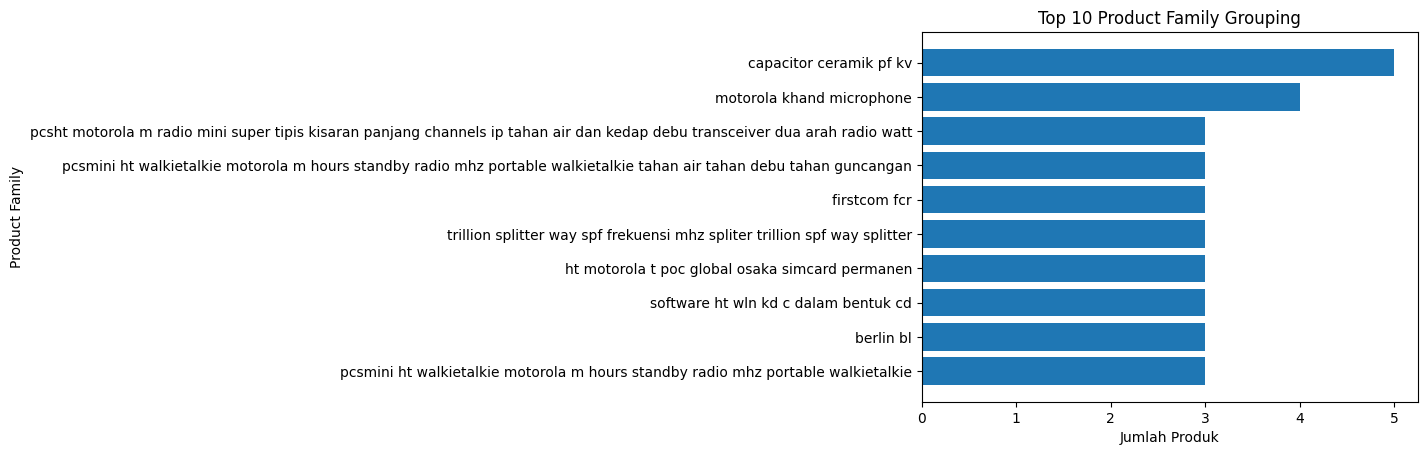

In [ ]:
# =========================
# 4. VISUALISASI (TOP 10)
# =========================
top_n = 10
top_data = group_df.head(top_n)

plt.figure()

plt.barh(top_data["Product Family"], top_data["Jumlah Produk"])

plt.xlabel("Jumlah Produk")
plt.ylabel("Product Family")
plt.title("Top 10 Product Family Grouping")

plt.gca().invert_yaxis()  # biar terbesar di atas
plt.tight_layout()

# simpan gambar
plt.savefig("visualisasi_produk.png")

# tampilkan
plt.show()


In [ ]:
# =========================
# 5. (OPSIONAL) PRINT HASIL
# =========================
print("\nTop Product Family:")
print(top_data)


Top Product Family:
                                         Product Family  Jumlah Produk
260                             capacitor ceramik pf kv              5
1040                          motorola khand microphone              4
1125  pcsht motorola m radio mini super tipis kisara...              3
1126  pcsmini ht walkietalkie motorola m hours stand...              3
416                                        firstcom fcr              3
200   trillion splitter way spf frekuensi mhz splite...              3
1263    ht motorola t poc global osaka simcard permanen              3
689                software ht wln kd c dalam bentuk cd              3
272                                           berlin bl              3
1254  pcsmini ht walkietalkie motorola m hours stand...              3
